In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [3]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [5]:
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns.")

There are 74 rows and 20 columns.


In [6]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

#### *Now, here comes some Basic Questions*

###### *1. Which team won the most matches?*

In [7]:
match_wins = df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0, 0.5, 'Teams')

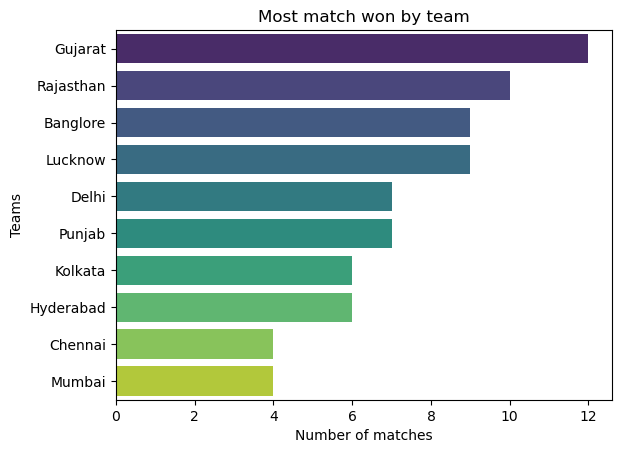

In [8]:
sns.barplot(y = match_wins.index, x = match_wins.values, palette = 'viridis')
plt.title('Most match won by team')
plt.xlabel('Number of matches')
plt.ylabel('Teams')

#### *2. Toss Decision Trend*

Text(0.5, 1.0, 'Toss Decision Trend')

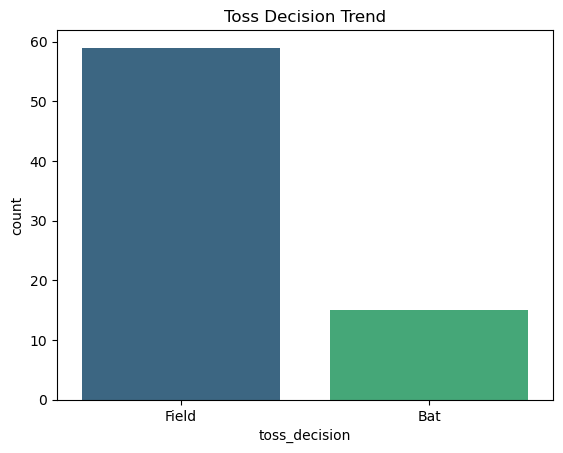

In [16]:
sns.countplot(x = df['toss_decision'], palette='viridis')
plt.title('Toss Decision Trend')

#### *3. Toss Winner vs Match Winner*

In [10]:
count = df[df['toss_winner'] == df['match_winner']]['match_winner'].count()
percentage = count * 100 / df.shape[0]

In [11]:
print(percentage.round(2))

48.65


#### *4. How do teams win? Runs vs Wickets*

In [17]:
df['won_by'].max()

'Wickets'

<Axes: xlabel='won_by', ylabel='count'>

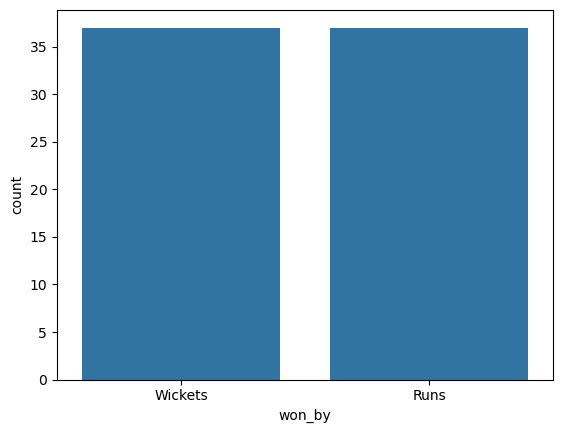

In [13]:
sns.countplot(x = df['won_by'])

## Key Player Performances

#### *1. Most 'Player of the Match' Awards*

Text(0.5, 1.0, 'Top 10 playes who won most man of the match')

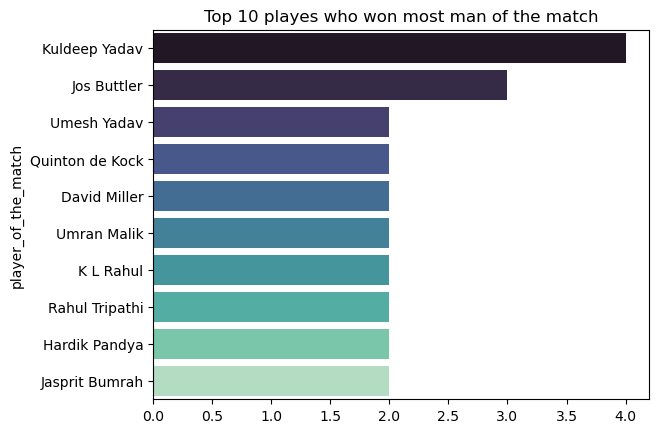

In [14]:
count = df['player_of_the_match'].value_counts().head(10)
sns.barplot(y = count.index, x = count.values, palette='mako')
plt.title('Top 10 playes who won most man of the match')

#### *2. Two Top Scorers*

<Axes: xlabel='top_scorer'>

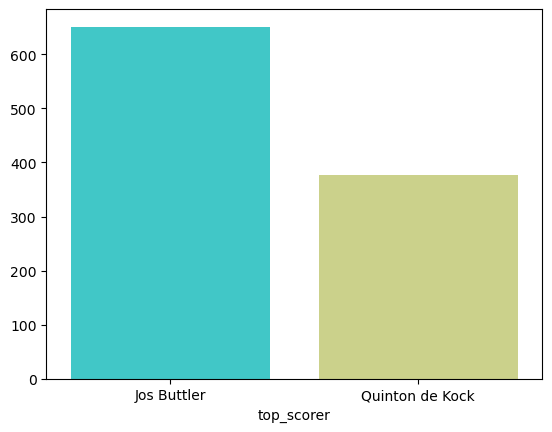

In [15]:
top_scores = df.groupby(df['top_scorer'])['highscore'].sum().sort_values(ascending=False).head(2)
sns.barplot(x = top_scores.index, y = top_scores.values, palette='rainbow' )

#### *3. 10 best bowling figures*

In [51]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)

In [57]:
top_bowlers = df.groupby(df['best_bowling'])['highest_wickets'].sum().sort_values(ascending=False).head(10)

In [55]:
top_bowlers.head()

best_bowling
Yuzvendra Chahal    17
Kuldeep Yadav       11
Rashid Khan         11
Jasprit Bumrah      11
Avesh Khan          10
Name: highest_wickets, dtype: int64

<Axes: ylabel='best_bowling'>

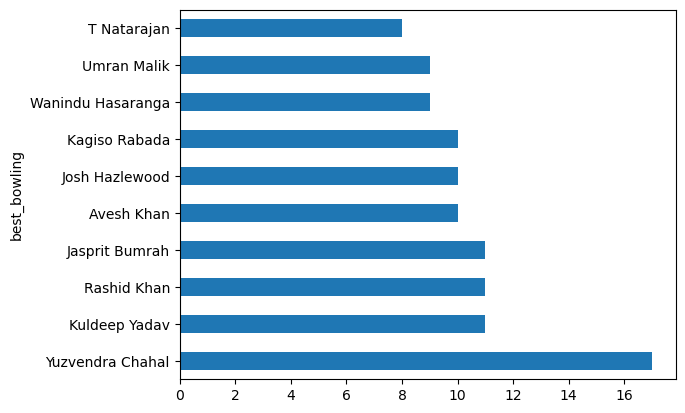

In [58]:
top_bowlers.plot(kind = 'barh')

### *Venue Analysis*

#### *Most matches played by venue*

In [59]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure', 'highest_wickets'],
      dtype='object')

In [62]:
venue_count = df['venue'].value_counts()

In [63]:
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

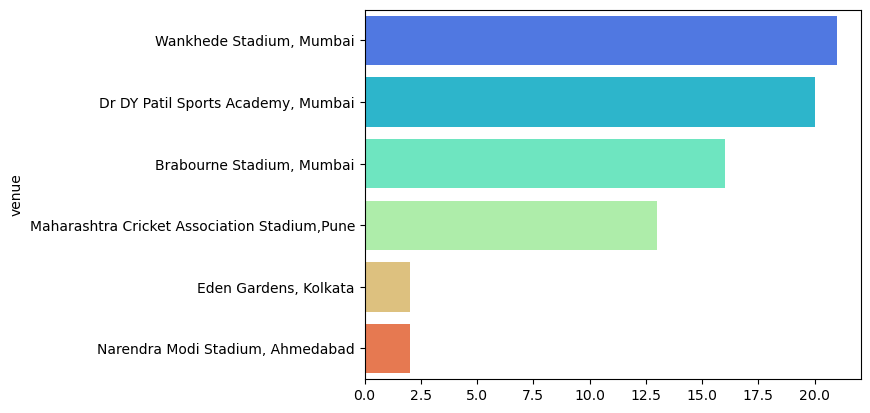

In [66]:
sns.barplot(y = venue_count.index, x = venue_count.values, palette='rainbow')

### *Custom Questions & Insights*

#### *1. Who won the highest margin by runs*

In [77]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin' ,ascending=False)[['team1', 'team2', 'match_winner', 'margin', 'won_by']].head(1)

,team1,team2,match_winner,margin,won_by
54,Chennai,Delhi,Chennai,91,Runs


#### *2. Which player had the highest individual score?*

In [79]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure', 'highest_wickets'],
      dtype='object')

In [85]:
df[df['highscore'] == df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


#### *3. Which bowler has the best bowling figures?*

In [86]:
df[df['highest_wickets'] == df['highest_wickets'].max()]['best_bowlin']

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
29,30,"April 18,2022","Brabourne Stadium, Mumbai",Kolkata,Rajasthan,Group,Kolkata,Field,217,5,...,10,Rajasthan,Runs,7,Yuzvendra Chahal,Jos Buttler,103,Yuzvendra Chahal,5--40,5
39,40,"April 27,2022","Wankhede Stadium, Mumbai",Gujarat,Hyderabad,Group,Gujarat,Field,195,6,...,5,Gujarat,Wickets,5,Umran Malik,W. Saha,68,Umran Malik,5--25,5
53,54,"May 8,2022","Wankhede Stadium, Mumbai",Banglore,Hyderabad,Group,Banglore,Bat,192,3,...,10,Banglore,Runs,67,Wanindu Hasaranga,Faf du Plessis,73,Wanindu Hasaranga,5--18,5
55,56,"May 9,2022","Dr DY Patil Sports Academy, Mumbai",Kolkata,Mumbai,Group,Mumbai,Field,165,9,...,10,Kolkata,Runs,52,Jasprit Bumrah,Ishan Kishan,51,Jasprit Bumrah,5--10,5
